# Notebook — Teste do módulo `io.py`

Teste de leitura/escrita de arquivos `longitude latitude valor`, transformação `xyz_to_grid` e leitura de dados reais em `geodesy_input/`.


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
current_dir = Path.cwd()
if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
import geodesy
from geodesy import io
print("Versão:", geodesy.__version__)


Versão: 0.1.0


In [2]:
# 1. Criar arquivo sintético
outdir = Path("geodesy_input"); outdir.mkdir(exist_ok=True)
lon = np.linspace(-55,-50,80); lat = np.linspace(-5,-1,60)
LON, LAT = np.meshgrid(lon,lat)
Z = 100 + 500*np.exp(-((LON+52.5)**2+(LAT+3)**2)/0.7) - 120*np.exp(-((LON+53.8)**2+(LAT+2)**2)/0.25)
xv,yv,zv = io.grid_to_xyz(LON,LAT,Z)
arquivo = outdir/"teste_io_topografia.txt"
io.write_xyz_file(arquivo,xv,yv,zv,header="longitude latitude topografia",fmt="%.10f")
print("Salvo:", arquivo, "linhas:", len(zv))


Salvo: geodesy_input\teste_io_topografia.txt linhas: 4800


In [3]:
# 2. Ler arquivo
lon_read, lat_read, z_read = io.read_xyz_file(arquivo, skiprows=1)
print(lon_read.min(), lon_read.max(), lat_read.min(), lat_read.max(), z_read.min(), z_read.max())


-55.0 -50.0 -5.0 -1.0 -9.6955544878 598.4648733153


In [4]:
# 3. Verificar grade regular
regular,nx,ny = io.check_regular_grid(lon_read,lat_read)
print("regular:", regular, "nx:", nx, "ny:", ny, "total esperado:", nx*ny, "lido:", len(z_read))


regular: True nx: 80 ny: 60 total esperado: 4800 lido: 4800


(60, 80) (60, 80) (60, 80) NaN: 0


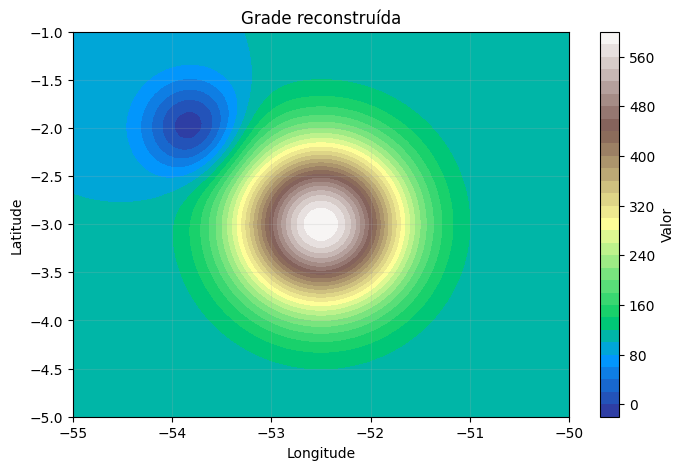

In [5]:
# 4. XYZ -> GRID
XG,YG,ZG = io.xyz_to_grid(lon_read, lat_read, z_read)
print(XG.shape, YG.shape, ZG.shape, "NaN:", np.isnan(ZG).sum())
plt.figure(figsize=(8,5))
c=plt.contourf(XG,YG,ZG,levels=30,cmap="terrain")
plt.colorbar(c,label="Valor"); plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Grade reconstruída"); plt.grid(alpha=.2); plt.show()


In [6]:
# 5. GRID -> XYZ e salvar
x2,y2,z2 = io.grid_to_xyz(XG,YG,ZG)
arquivo2 = outdir/"teste_io_topografia_saida.txt"
io.write_xyz_file(arquivo2,x2,y2,z2,header="longitude latitude valor",fmt="%.10f")
print("Salvo:", arquivo2)


Salvo: geodesy_input\teste_io_topografia_saida.txt


In [7]:
# 6. Ler arquivos reais se existirem
arquivos = [Path("geodesy_input/topografia.txt"), Path("geodesy_input/disturbio.txt"), Path("geodesy_input/geoide.txt")]
for arq in arquivos:
    print("\nArquivo:", arq)
    if arq.exists():
        x,y,z = io.read_lon_lat_value(arq, skiprows=0)
        regular,nx,ny = io.check_regular_grid(x,y)
        print("pontos:", len(z), "regular:", regular, "nx:", nx, "ny:", ny)
        print("lon:", x.min(), x.max(), "lat:", y.min(), y.max(), "valor:", np.nanmin(z), np.nanmax(z))
    else:
        print("não encontrado")



Arquivo: geodesy_input\topografia.txt
pontos: 60501 regular: True nx: 201 ny: 301
lon: -50.0 -40.0 lat: -10.0 5.0 valor: -4969.59199 962.52968

Arquivo: geodesy_input\disturbio.txt
pontos: 60501 regular: True nx: 201 ny: 301
lon: -50.0 -40.0 lat: -10.0 5.0 valor: -98.51987 82.99106

Arquivo: geodesy_input\geoide.txt
pontos: 60501 regular: True nx: 201 ny: 301
lon: -50.0 -40.0 lat: -10.0 5.0 valor: -36.51482 -9.81037


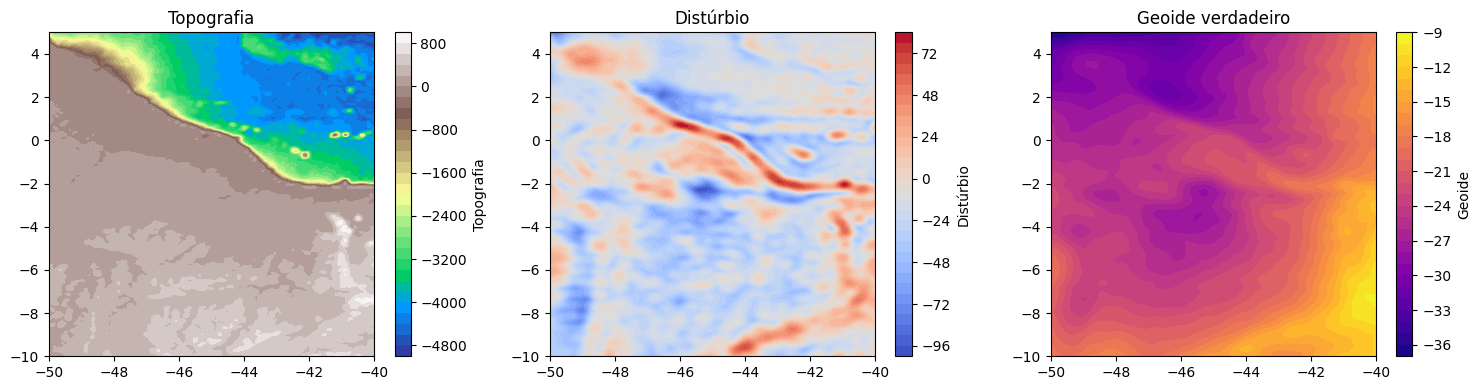

In [15]:
# 7. Painel dos arquivos reais se existirem
topo_file=Path("geodesy_input/topografia.txt")
dist_file=Path("geodesy_input/disturbio.txt")
geoide_file=Path("geodesy_input/geoide.txt")
if topo_file.exists() and dist_file.exists() and geoide_file.exists():
    lon_t,lat_t,topo=io.read_lon_lat_value(topo_file,skiprows=0)
    lon_d,lat_d,dist=io.read_lon_lat_value(dist_file,skiprows=0)
    lon_g,lat_g,geoide=io.read_lon_lat_value(geoide_file,skiprows=0)
    LON_T,LAT_T,TOPO=io.xyz_to_grid(lon_t,lat_t,topo)
    LON_D,LAT_D,DIST=io.xyz_to_grid(lon_d,lat_d,dist)
    LON_G,LAT_G,GEOIDE=io.xyz_to_grid(lon_g,lat_g,geoide)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1); c1=plt.contourf(LON_T,LAT_T,TOPO,levels=30,cmap="terrain"); plt.colorbar(c1,label="Topografia"); plt.title("Topografia")
    plt.subplot(1,3,2); c2=plt.contourf(LON_D,LAT_D,DIST,levels=30,cmap="coolwarm"); plt.colorbar(c2,label="Distúrbio"); plt.title("Distúrbio")
    plt.subplot(1,3,3); c3=plt.contourf(LON_G,LAT_G,GEOIDE,levels=30,cmap="plasma"); plt.colorbar(c3,label="Geoide"); plt.title("Geoide verdadeiro")
    plt.tight_layout(); plt.show()
else:
    print("Os três arquivos reais ainda não estão disponíveis em geodesy_input/.")